# <u>Linear Regression Lab</u>

 Regression lab, using the same **Boston** and **Carseats** examples.


In [1]:
#Installing required libraries 

#%pip install statsmodels ISLP

In [1]:
# 1. IMPORT LIBRARIES

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Load the Boston data


In [2]:
# 2. LOAD BOSTON DATA FROM LOCAL CSV

from ISLP import load_data

df = load_data("Boston")
df.columns = df.columns.str.lower()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())


Shape: (506, 13)

Columns:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat', 'medv']

First 5 rows:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
# Basic inspection

print("Dataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB

Summary statistics:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


## 3. Simple Linear Regression

We predict `medv` from `lstat`:

\[
medv = \beta_0 + \beta_1(lstat)
\]


In [4]:
# Simple linear regression

model = smf.ols("medv ~ lstat", data=df).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           5.08e-88
Time:                        21:36:54   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.5538      0.563     61.415      0.0

In [5]:
# Coefficients

print("Coefficients:")
display(model.params)

print("\nP-values:")
display(model.pvalues)

print("\nR-squared:", round(model.rsquared, 3))
print("Adjusted R-squared:", round(model.rsquared_adj, 3))


Coefficients:


Intercept    34.553841
lstat        -0.950049
dtype: float64


P-values:


Intercept    3.743081e-236
lstat         5.081103e-88
dtype: float64


R-squared: 0.544
Adjusted R-squared: 0.543


### <u>Interpretation reminder</u>

- A **negative coefficient** for `lstat` means higher `lstat` is associated with lower predicted `medv`.
- A **small p-value** (commonly < 0.05) provides evidence that the predictor is statistically significant.
- **R²** is the proportion of variation in the response explained by the model.


In [6]:
# 95% confidence intervals for coefficients

print("95% Confidence Intervals:")
display(model.conf_int(alpha=0.05))


95% Confidence Intervals:


,0,1
Intercept,33.448457,35.659225
lstat,-1.026148,-0.873951


## <u>Predictions and intervals</u>

In [7]:
# Predict medv for lstat = 5, 10, 15

new_data = pd.DataFrame({"lstat": [5, 10, 15]})

prediction = model.get_prediction(new_data)
prediction_table = prediction.summary_frame(alpha=0.05)

display(prediction_table)


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,29.803594,0.405247,29.007412,30.599776,17.565675,42.041513
1,25.053347,0.294814,24.474132,25.632563,12.827626,37.279068
2,20.303101,0.290893,19.731588,20.874613,8.077742,32.528459


In the prediction output:

- `mean` = predicted mean response
- `mean_ci_lower`, `mean_ci_upper` = confidence interval for the mean
- `obs_ci_lower`, `obs_ci_upper` = prediction interval for an individual observation


## <u>Regression plot</u>

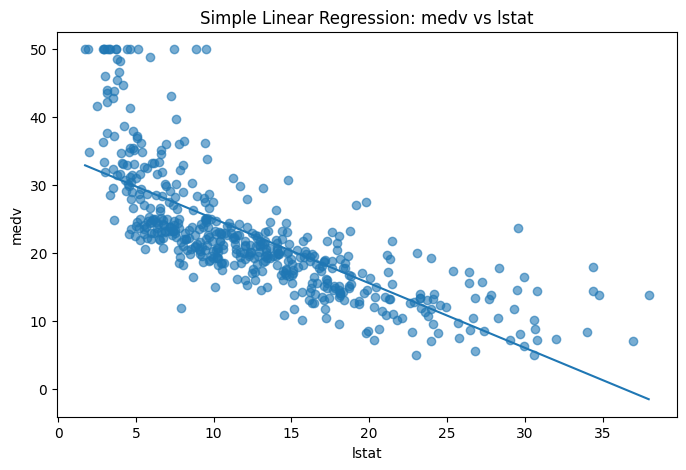

In [8]:
# Scatter plot and fitted regression line

sorted_df = df.sort_values("lstat")

plt.figure(figsize=(8, 5))
plt.scatter(df["lstat"], df["medv"], alpha=0.6)
plt.plot(sorted_df["lstat"], model.predict(sorted_df))
plt.xlabel("lstat")
plt.ylabel("medv")
plt.title("Simple Linear Regression: medv vs lstat")
plt.show()


## <u>Residual diagnostics</u>

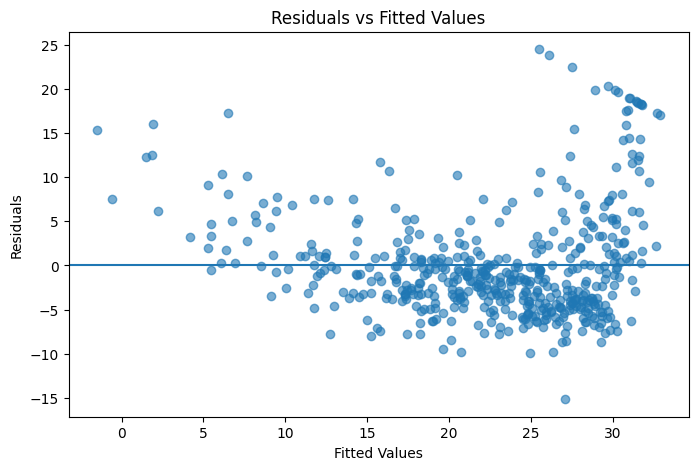

In [9]:
# Residuals versus fitted values

plt.figure(figsize=(8, 5))
plt.scatter(model.fittedvalues, model.resid, alpha=0.6)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


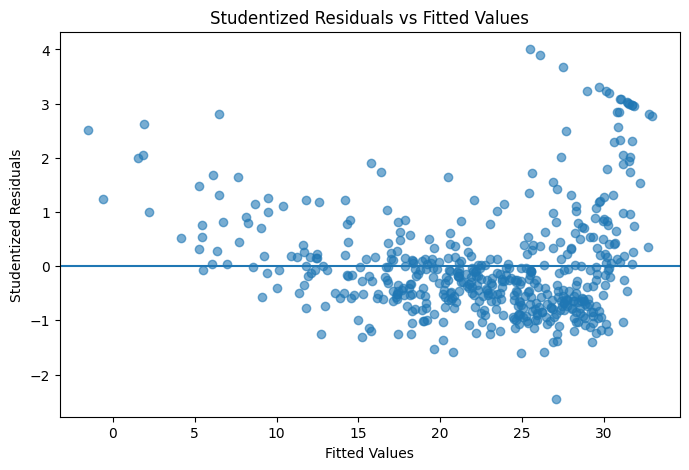

In [10]:
# Studentized residuals versus fitted values

influence = model.get_influence()
studentized_residuals = influence.resid_studentized_external

plt.figure(figsize=(8, 5))
plt.scatter(model.fittedvalues, studentized_residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Studentized Residuals")
plt.title("Studentized Residuals vs Fitted Values")
plt.show()


##  <u>Leverage</u>

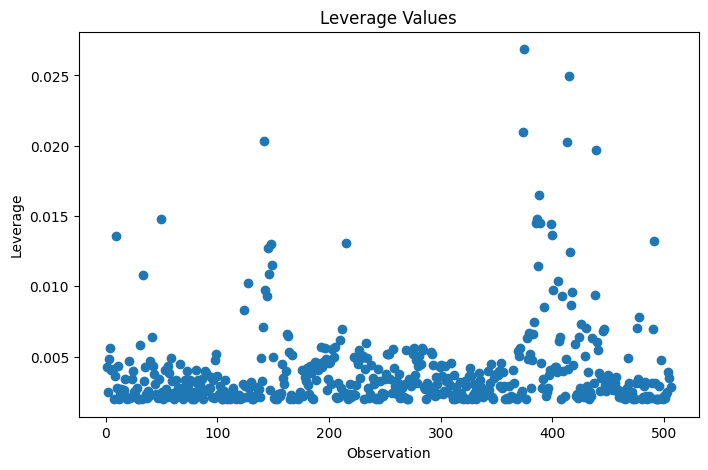

Observation with highest leverage: 375


In [11]:
# Leverage values

influence = model.get_influence()

leverage = influence.hat_matrix_diag
plt.figure(figsize=(8, 5))
plt.scatter(range(1, len(leverage) + 1), leverage)
plt.xlabel("Observation")
plt.ylabel("Leverage")
plt.title("Leverage Values")
plt.show()
highest_leverage_index = np.argmax(leverage) + 1
print("Observation with highest leverage:", highest_leverage_index)


## <u>Multiple Linear Regression</u>

Predict `medv` using `lstat` and `age`.


In [12]:
multiple_model = smf.ols(
    "medv ~ lstat + age",
    data=df
).fit()

print(multiple_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     309.0
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           2.98e-88
Time:                        21:37:49   Log-Likelihood:                -1637.5
No. Observations:                 506   AIC:                             3281.
Df Residuals:                     503   BIC:                             3294.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     33.2228      0.731     45.458      0.0

## <u>Multiple Regression Using All Predictors</u>

In [13]:
# All predictors

predictor_columns = [col for col in df.columns if col != "medv"]

formula_all = "medv ~ " + " + ".join(predictor_columns)
all_model = smf.ols(formula_all, data=df).fit()

print(all_model.summary())

print("\nR-squared:", round(all_model.rsquared, 3))
print("Adjusted R-squared:", round(all_model.rsquared_adj, 3))
print("Residual standard error:", round(np.sqrt(all_model.mse_resid), 3))


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Sun, 16 Aug 2026   Prob (F-statistic):          2.23e-133
Time:                        21:37:58   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.6173      4.936      8.431      0.0

## <u>Multicollinearity — VIF</u>

VIF helps detect predictors that are strongly explained by other predictors.

Common rule of thumb:

- VIF around 1: little/no multicollinearity
- VIF > 5: possible concern
- VIF > 10: often considered serious


In [14]:
# Calculate VIF with an intercept, then omit the intercept from the displayed table.

X_vif = df.drop(columns=["medv"]).astype(float)
X_vif_const = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

vif_table = vif_table[vif_table["Variable"] != "const"].reset_index(drop=True)

display(vif_table.sort_values("VIF", ascending=False))


,Variable,VIF
9,tax,9.002158
8,rad,7.445301
4,nox,4.369093
2,indus,3.987181
7,dis,3.954037
6,age,3.088232
11,lstat,2.870777
1,zn,2.298459
5,rm,1.912532
10,ptratio,1.797060


## <u>Model Without `age` </u>

In [15]:
predictors_no_age = [
    col for col in df.columns
    if col not in ["medv", "age"]
]

formula_no_age = "medv ~ " + " + ".join(predictors_no_age)

model_no_age = smf.ols(
    formula_no_age,
    data=df
).fit()

print(model_no_age.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     124.1
Date:                Sun, 16 Aug 2026   Prob (F-statistic):          2.03e-134
Time:                        21:38:15   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3034.
Df Residuals:                     494   BIC:                             3085.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.5251      4.920      8.441      0.0

## <u>Interaction Terms</u>

`lstat * age` includes:

- `lstat`
- `age`
- `lstat:age`


In [16]:
interaction_model = smf.ols(
    "medv ~ lstat * age",
    data=df
).fit()

print(interaction_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     209.3
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           4.86e-88
Time:                        21:38:24   Log-Likelihood:                -1635.0
No. Observations:                 506   AIC:                             3278.
Df Residuals:                     502   BIC:                             3295.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.0885      1.470     24.553      0.0

## <u>Quadratic / Non-linear Regression</u>

In [17]:
# Linear model

linear_model = smf.ols(
    "medv ~ lstat",
    data=df
).fit()

# Quadratic model
quadratic_model = smf.ols(
    "medv ~ lstat + I(lstat ** 2)",
    data=df
).fit()

print(quadratic_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     448.5
Date:                Sun, 16 Aug 2026   Prob (F-statistic):          1.56e-112
Time:                        21:39:31   Log-Likelihood:                -1581.3
No. Observations:                 506   AIC:                             3169.
Df Residuals:                     503   BIC:                             3181.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        42.8620      0.872     49.149

## <u>Compare Linear and Quadratic Models with ANOVA</u>

<b>Null hypothesis</b>: both models fit equally well.

<b>Alternative hypothesis</b>: the larger quadratic model gives a better fit.


In [18]:
anova_result = anova_lm(
    linear_model,
    quadratic_model
)

display(anova_result)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,504.0,19472.381418,0.0,NaN,NaN,NaN
1,503.0,15347.243158,1.0,4125.13826,135.199822,7.630116e-28


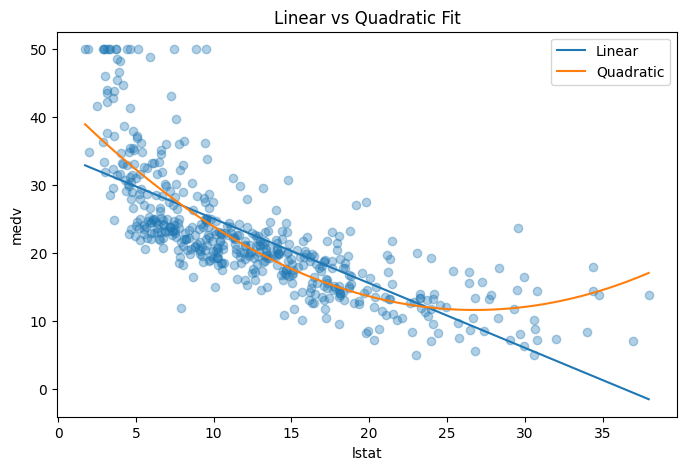

In [19]:
# Plot linear and quadratic fits

x_grid = np.linspace(df["lstat"].min(), df["lstat"].max(), 300)
plot_data = pd.DataFrame({"lstat": x_grid})

plt.figure(figsize=(8, 5))
plt.scatter(df["lstat"], df["medv"], alpha=0.35)
plt.plot(x_grid, linear_model.predict(plot_data), label="Linear")
plt.plot(x_grid, quadratic_model.predict(plot_data), label="Quadratic")
plt.xlabel("lstat")
plt.ylabel("medv")
plt.title("Linear vs Quadratic Fit")
plt.legend()
plt.show()


## <u>Fifth-order Polynomial Regression </u>

This Python version uses raw powers of `lstat`. The fitted curve can be compared with the polynomial model in R.


In [20]:
polynomial_model = smf.ols(
    "medv ~ lstat + I(lstat**2) + I(lstat**3) + I(lstat**4) + I(lstat**5)",
    data=df
).fit()

print(polynomial_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     214.2
Date:                Sun, 16 Aug 2026   Prob (F-statistic):          8.73e-122
Time:                        21:40:41   Log-Likelihood:                -1550.6
No. Observations:                 506   AIC:                             3113.
Df Residuals:                     500   BIC:                             3139.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        67.6997      3.604     18.783

## <u>Log Transformation</u>

In [21]:
log_model = smf.ols(
    "medv ~ np.log(rm)",
    data=df
).fit()

print(log_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     389.3
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           1.22e-64
Time:                        21:40:50   Log-Likelihood:                -1695.4
No. Observations:                 506   AIC:                             3395.
Df Residuals:                     504   BIC:                             3403.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -76.4878      5.028    -15.213      0.0

# Carseats: Qualitative / Categorical Predictors

The next section demonstrates how Python handles categorical predictors and interactions.


In [22]:
# 17. LOAD CARSEATS DATA

from ISLP import load_data

carseats = load_data("Carseats")
carseats.columns = carseats.columns.str.lower()

print("Shape:", carseats.shape)
display(carseats.head())


Shape: (400, 11)


,sales,compprice,income,advertising,population,price,shelveloc,age,education,urban,us
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [23]:
# Inspect categories

print("ShelveLoc categories:", carseats["shelveloc"].unique())
print("Urban categories:", carseats["urban"].unique())
print("US categories:", carseats["us"].unique())


ShelveLoc categories: ['Bad', 'Good', 'Medium']
Categories (3, object): ['Bad', 'Good', 'Medium']
Urban categories: ['Yes', 'No']
Categories (2, object): ['No', 'Yes']
US categories: ['Yes', 'No']
Categories (2, object): ['No', 'Yes']


## <u>Carseats Multiple Regression with Interactions </u>

`Bad` is explicitly used as the reference category for `ShelveLoc`, matching the interpretation in the lab.


In [24]:
carseats_formula = '''
sales ~ compprice + income + advertising + population + price
      + C(shelveloc, Treatment(reference="Bad"))
      + age + education
      + C(urban, Treatment(reference="No"))
      + C(us, Treatment(reference="No"))
      + income:advertising
      + price:age
'''
carseats_model = smf.ols(
    carseats_formula,
    data=carseats
).fit()
print(carseats_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     210.0
Date:                Sun, 16 Aug 2026   Prob (F-statistic):          6.14e-166
Time:                        21:41:10   Log-Likelihood:                -564.67
No. Observations:                 400   AIC:                             1157.
Df Residuals:                     386   BIC:                             1213.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

## <u>Dummy-variable coding for `ShelveLoc`</u>

With `Bad` as the reference:

- Bad → Good = 0, Medium = 0
- Good → Good = 1, Medium = 0
- Medium → Good = 0, Medium = 1


In [25]:
dummy_example = pd.get_dummies(
    carseats["shelveloc"],
    prefix="shelveloc",
    drop_first=False,
    dtype=int
)
display(pd.concat(
    [carseats[["shelveloc"]].head(10), dummy_example.head(10)],
    axis=1
))


,shelveloc,shelveloc_Bad,shelveloc_Good,shelveloc_Medium
0,Bad,1,0,0
1,Good,0,1,0
2,Medium,0,0,1
3,Medium,0,0,1
4,Bad,1,0,0
5,Bad,1,0,0
6,Medium,0,0,1
7,Good,0,1,0
8,Medium,0,0,1
9,Medium,0,0,1
